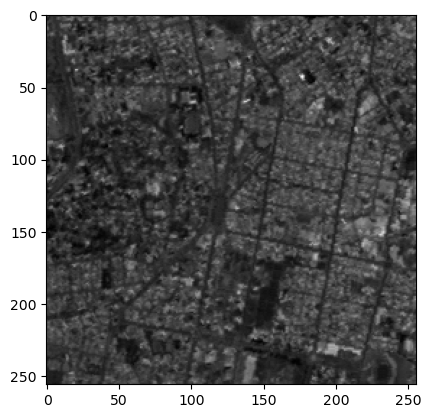

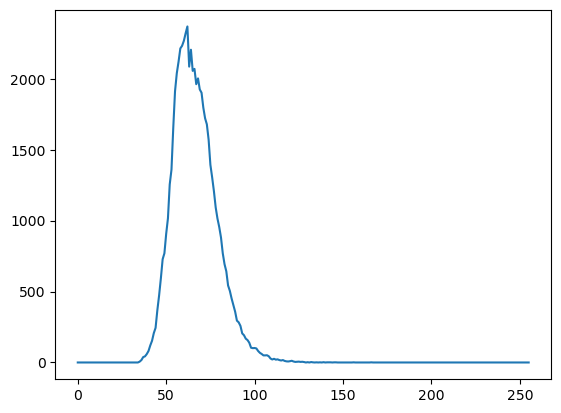

In [10]:
import cv2
import matplotlib.pyplot as plt

quito = cv2.imread('QUITO.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(quito, cmap='gray')
plt.show()

hist = cv2.calcHist([quito],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()




# ¿Cuáles son los niveles de gris mínimo y máximo?

En el histograma podemos ver que la mayoría de los niveles de intensidad se encuentran rondando los 60. Por otro lado, parece ser que el nivel mínimo de grises está cerca de 40 mientras que el nivel máximo casi lleba a 150.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16160\3819691411.py:7: RuntimeWarning: overflow encountered in scalar subtract
  beta = -255 * (B / (B - A))


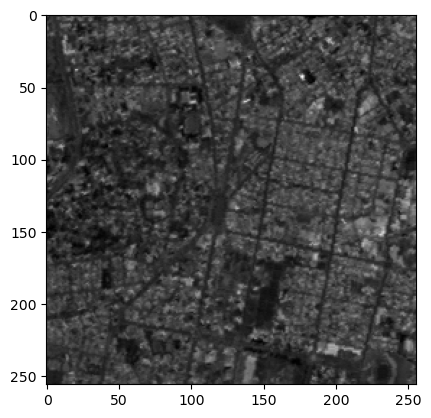

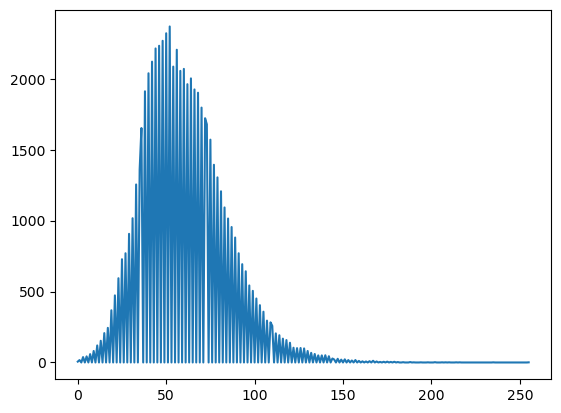

In [19]:
import numpy as np
from skimage import exposure

A = np.max(quito)
B = np.min(quito)
alpha = 255 / (A - B)
beta = -255 * (B / (B - A))
quitoExp = exposure.rescale_intensity(quito, in_range=(B, A))

plt.imshow(quitoExp, cmap='gray')
plt.show()
hist = cv2.calcHist([quitoExp],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()


# ¿En qué consiste la mejora de la imagen?

La mejora en la imagen es casi inperceptible, pero el cambio si se nota en su histograma. Lo que se hizo al expandir la imagen fue distribuir todas las intensidades de la imagen original en la escala completa de grises. Esto hace más visibles los detalles en zonas de bajo contraste. Podemos ver que ahora si el valor de menor intensidad es 0 y el de mayor seguramente es un unico pixel de 255.

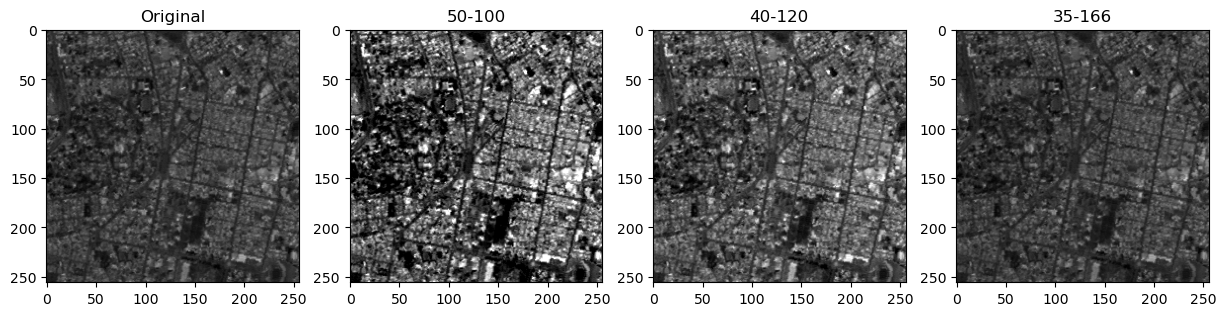

In [21]:
rangos = [(50, 100), (40, 120), (35, 166)]
calibradas = []
for B, A in rangos:
    calibrada = exposure.rescale_intensity(quito, in_range=(B, A))
    calibradas.append(calibrada)

fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs[0].imshow(quito, cmap='gray')
axs[0].set_title('Original')
for i, (img, (B, A)) in enumerate(zip(calibradas, rangos)):
    axs[i+1].imshow(img, cmap='gray')
    axs[i+1].set_title(f'{B}-{A}')

plt.show()


# ¿Cuál es la diferencia entre estas imágenes? ¿Cuál presenta el mejor contraste? ¿Cuál permite ver mejor los detalles? ¿Por qué la calibración entre 35 y 166 da el mismo resultado que la expansión del contraste efectuada en el punto 4? ¿Conclusión?

La calibración de 50-100 comprime la imagen a un rango de niveles de gris muy reducido. Cualquier detalle que esté fuera de este rango se pierden y a simple vista la imagen se muestra muy saturada. Por otro lado, la calibración de 40-120 expande la imagen en un rango un poco más amplio de niveles de gris, mejorando el contraste en algunas regiones y conservando más detalles que la calibración de 50-100. Finalmente, la calibración de 35-166 se ve igual a la expansión en el punto anterior porque al ver el histograma de la imagen original, podremos ver que de por sí la escala de grises solo existe dentro de estos valores. Teniendo todo esto en cuenta, la imagen que en teoría debería verse mejor sería la del rango de 35-166 porque es la que pierde menos detalles aunque las intencidades que ocupa la imagen son muy cercanas, pero en lo personal me parece que la imagen con mejor contraste es la de 40-120, ya que se puede apreciar la diferencia entre los tonos más claros y más oscuros. En conclusión, la calibración del histograma ajusta el contraste de la imagen, y el mejor resultado se obtiene cuando se usa el rango completo de intensidades sin perder detalles.